# **Importing** **Required** **Libraries**
### In this section we import the necessary Python libraries used for data analysis, visualization, and machine learning.

In [1]:
# importing basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Loading** **the** **Dataset**
### Here we load the startup dataset using pandas to begin exploring the data.

In [2]:
# uploading data
df=pd.read_csv('startups.csv')
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,76378.263234,142264.356098,143824.804549,Florida,99239.980393
1,4315.954684,116130.137235,297712.356857,Florida,50980.489819
2,74749.042455,142415.350771,134881.565517,Florida,108997.903673
3,61649.258471,139980.092354,138594.135358,California,111353.080508
4,27558.006549,117774.052123,171962.461409,California,77206.257147


# **Data** **Understanding**
### This step helps us understand the structure of the dataset including the number of rows, columns, and data types.

In [3]:
df.shape

(10000, 5)

In [4]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,74109.844662,120968.618113,208076.805990,111893.729052
std,45522.472100,28099.122799,121690.902429,40243.639831
min,0.000000,46119.282827,0.000000,9223.181846
25%,36472.498035,101944.983154,123827.712979,86495.149493
50%,72734.439932,122588.760836,209790.707773,107914.810899
75%,104231.330683,144739.350043,300398.942460,141892.546693
max,171880.983112,185459.879787,486765.953885,198537.042385


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        10000 non-null  float64
 1   Administration   10000 non-null  float64
 2   Marketing Spend  10000 non-null  float64
 3   State            10000 non-null  object 
 4   Profit           10000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 390.8+ KB


# **Checking** **Missing** **Values**
### We check whether the dataset contains any missing values that may affect model performance.

In [6]:
df.isnull().sum()

,0
R&D Spend,0
Administration,0
Marketing Spend,0
State,0
Profit,0


# **Checking** **Duplicate** **Records**
### This step ensures there are no duplicate rows in the dataset.

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        10000 non-null  float64
 1   Administration   10000 non-null  float64
 2   Marketing Spend  10000 non-null  float64
 3   State            10000 non-null  object 
 4   Profit           10000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 390.8+ KB


# **Encoding** **Categorical** **Variables**
### Since machine learning models require numerical data, we convert categorical variables into numerical values using Label Encoding.

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['State_encoded'] = le.fit_transform(df['State'])

In [10]:
df.corr(numeric_only=True)

,R&D Spend,Administration,Marketing Spend,Profit,State_encoded
R&D Spend,1.000000,0.233356,0.729742,0.970350,0.103383
Administration,0.233356,1.000000,-0.034465,0.198771,0.031721
Marketing Spend,0.729742,-0.034465,1.000000,0.752547,0.077123
Profit,0.970350,0.198771,0.752547,1.000000,0.100349
State_encoded,0.103383,0.031721,0.077123,0.100349,1.000000


# **Data** **Visualization**
### Visualization helps us understand relationships between variables and detect patterns or outliers in the dataset.

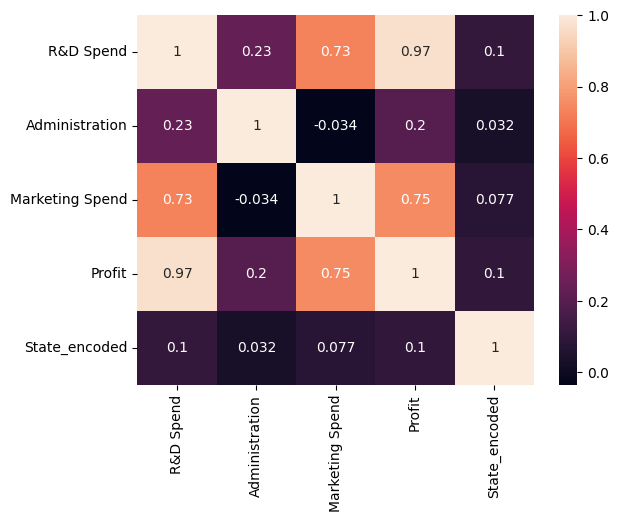

In [11]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

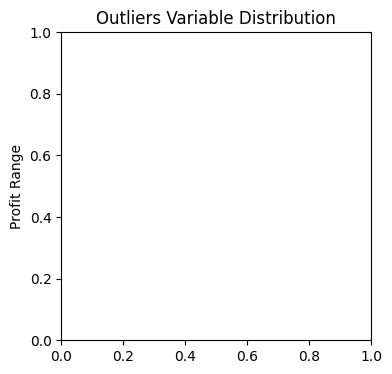

In [12]:
outliers = ['Profit']
plt.rcParams['figure.figsize'] = [4,4]
sns.boxplot(df= df[outliers], orient="v", palette="husl", width=0.7)

plt.title("Outliers Variable Distribution")
plt.ylabel("Profit Range")
plt.show()

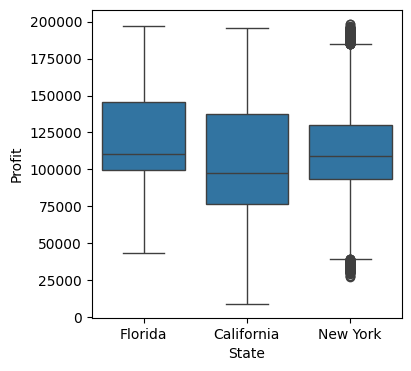

In [13]:
sns.boxplot(x='State',y='Profit',data=df)
plt.show()

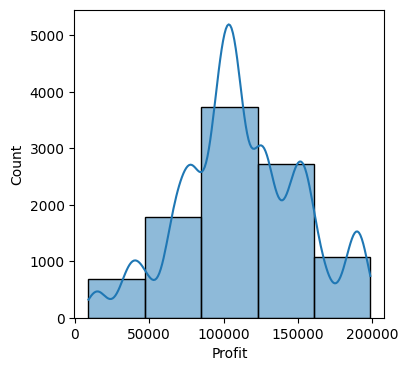

In [14]:
sns.histplot(df['Profit'], bins=5, kde=True)
plt.show()

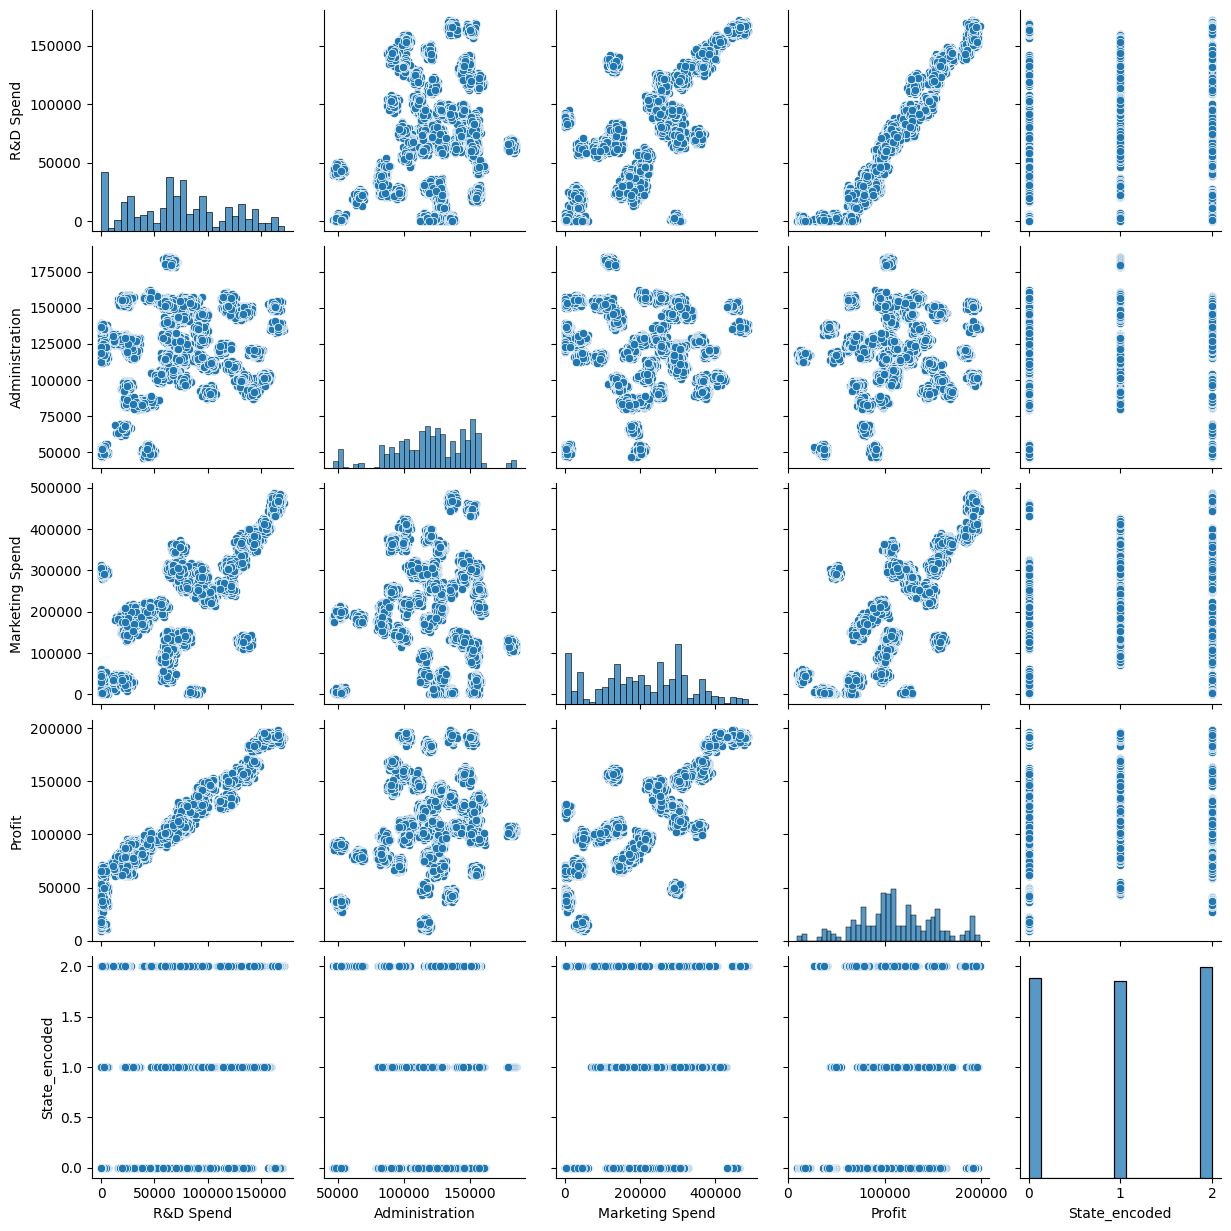

In [15]:
sns.pairplot(df)
plt.show()


# **Simple** **Linear** **Regression**
### In this section we build a simple linear regression model using one independent variable (R&D Spend) to predict the profit.

In [16]:
X = df[['R&D Spend']]
y = df['Profit']

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [19]:
y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 92285024.47922486
R2 Score: 0.9416158817526139


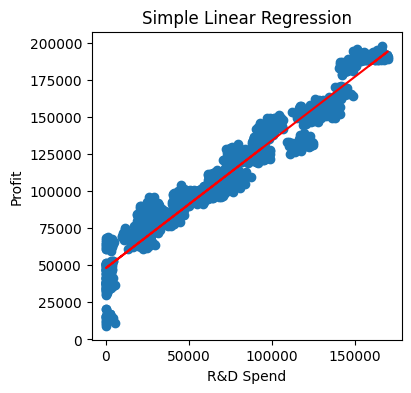

In [21]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred, color='red')
plt.xlabel("R&D Spend")
plt.ylabel("Profit")
plt.title("Simple Linear Regression")
plt.show()

# **Multiple** **Linear** **Regression**
### Here we use multiple independent variables to improve the prediction of profit.

In [22]:
# preparing data
x =df[["R&D Spend", "Administration", "Marketing Spend"]]
y =df["Profit"]

x = x.to_numpy()
y = y.to_numpy()
y = y.reshape(-1, 1)

In [23]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)


In [24]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
df_multiple_regression = pd.DataFrame({'Actual': y_test.flatten(), 'Predicted': y_pred.flatten()})
df_multiple_regression

,Actual,Predicted
0,128722.156981,130026.678697
1,106173.830462,99939.963804
2,15895.632802,47484.183822
3,146289.123668,135636.518522
4,140018.871303,128954.010653
...,...,...
2995,81833.113309,68626.957011
2996,105698.549483,95458.584443
2997,136512.260492,125573.542462
2998,102678.800945,102864.430131


In [25]:
print(model.intercept_) # b0
print(model.coef_) # b1 (Slope)

[47533.65656403]
[[ 0.80135469 -0.01147319  0.03034562]]


In [26]:
testing_data_model_score = model.score(x_test, y_test)
print("Model Scor/Performance on testing data", testing_data_model_score)


Model Scor/Performance on testing data 0.9453013881724146


In [27]:
training_data_model_score = model.score(x_train, y_train)
print("Model Scor/Performance on training data", training_data_model_score)

Model Scor/Performance on training data 0.9461107644673736


In [28]:
df_multiple_regression = pd.DataFrame({'Actual': y_test.flatten(), 'Predicted': y_pred.flatten()})
df_multiple_regression

,Actual,Predicted
0,128722.156981,130026.678697
1,106173.830462,99939.963804
2,15895.632802,47484.183822
3,146289.123668,135636.518522
4,140018.871303,128954.010653
...,...,...
2995,81833.113309,68626.957011
2996,105698.549483,95458.584443
2997,136512.260492,125573.542462
2998,102678.800945,102864.430131


In [29]:
# evaluate the model
from sklearn.metrics import r2_score
R2_Score = r2_score(y_test, y_pred)
print("R2 Score:", R2_Score)

R2 Score: 0.9453013881724146


In [30]:
from sklearn.metrics import mean_squared_error
MSE = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", MSE)

Mean Squared Error: 85427368.29131347


In [31]:
rmse = np.sqrt(MSE)
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 9242.692697007375


In [32]:
from sklearn.metrics import mean_absolute_error
MAE = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", MAE)

Mean Absolute Error: 7039.030633358223


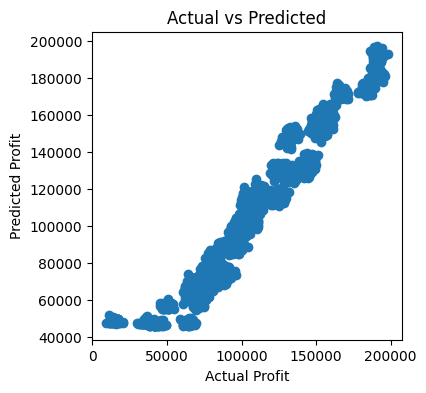

In [33]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted")
plt.show()

In [34]:
print(df.columns)

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit',
       'State_encoded'],
      dtype='object')


# **Polynomial** **Regression**
### Polynomial regression is used to capture nonlinear relationships between variables.

In [35]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(df[['R&D Spend']])

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

model_poly = LinearRegression()
model_poly.fit(X_train, y_train)

y_pred_poly = model_poly.predict(X_test)

In [37]:
print("MSE:", mean_squared_error(y_test, y_pred_poly))
print("R2 Score:", r2_score(y_test, y_pred_poly))

MSE: 91986837.5453855
R2 Score: 0.9418045297082637


In [38]:
from sklearn.metrics import mean_absolute_error  #error of test
mean_absolute_error(y_test,y_pred_poly)

7395.451218784262

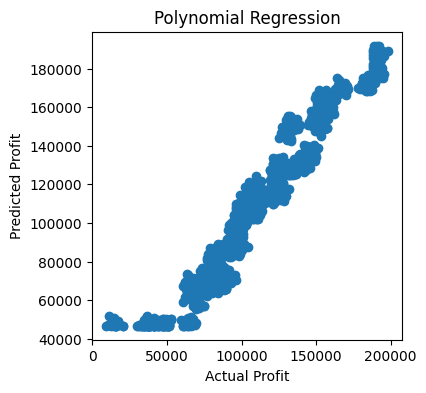

In [39]:
plt.scatter(y_test, y_pred_poly)
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Polynomial Regression")
plt.show()

# **Conclusion**

### After comparing the three models (Simple Linear Regression, Multiple Linear Regression, and Polynomial Regression), we observed that the models performed well with an R2 score close to 0.94.

### R&D Spend was the most influential feature affecting profit.

### Polynomial regression slightly improved the prediction accuracy, but the relationship between R&D Spend and Profit appears mostly linear.